### 1차원데이터분석
1) 변수종류파악( 수치형/범주형/시간형 )
2) 변수종류별분석지표( 수치형/범주형/시간형 )
 3) 시각화 : 도수분포표/히스토그램/상자그림

### 2차원데이터분석
1) 상관계수
2) 시각화 : 산점도/회귀직선/히트맵

# 항공사 지연요인 데이터 탐색적 분석
출처 : https://www.kaggle.com/datasets/pitterman/airline-stats

- airline : 항공사
- carrier_deay : 항공사 지연 요인
- atc_delay : ATC 항공교통관제 지연 요인
- weather_delay : 날씨로 인한 지연 요인

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv('./data/airline_stats.csv')
df

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American
...,...,...,...,...
33463,6.186422,8.798491,1.651940,Southwest
33464,9.522167,3.591133,0.261084,Southwest
33465,9.164179,2.664179,0.343284,Southwest
33466,5.152293,1.964520,0.122817,Southwest


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33468 entries, 0 to 33467
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pct_carrier_delay  33440 non-null  float64
 1   pct_atc_delay      33440 non-null  float64
 2   pct_weather_delay  33440 non-null  float64
 3   airline            33468 non-null  object 
dtypes: float64(3), object(1)
memory usage: 1.0+ MB


* pct_carrier_delay: 항공사 지연요인
* pct_atc_delay: 관제 지연요인
* pct_weather_Delay: 날씨 지연요인

# 항공사 현황 탐색

In [12]:
df.groupby('airline').size().sort_values(ascending=False)
# df['airline'].value_counts()

airline
Delta        9107
American     5725
Southwest    5584
United       5426
Alaska       3851
Jet Blue     3775
dtype: int64

# 수치형 변수들의 통계량 확인

In [13]:
df.describe()

,pct_carrier_delay,pct_atc_delay,pct_weather_delay
count,33440.000000,33440.000000,33440.000000
mean,7.041475,5.089962,0.684776
std,4.497596,4.718647,1.073743
min,0.000000,0.000000,0.000000
25%,4.145455,2.146565,0.000000
50%,6.356893,3.900000,0.316002
75%,9.140474,6.630238,0.935161
max,100.000000,100.000000,33.333333


## 항공사별 통계량

In [ ]:
df.groupby('airline')['pct_carrier_delay'].describe().T

airline,Alaska,American,Delta,Jet Blue,Southwest,United
count,3851.000000,5723.000000,9095.000000,3773.000000,5584.000000,5414.000000
mean,3.521889,9.042180,6.333460,8.081843,7.521997,7.398833
std,2.483224,4.139067,4.695292,3.797737,3.345085,5.369283
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.935484,6.338538,3.813989,5.341176,5.070294,4.034708
50%,3.225806,8.428571,5.548387,7.657895,6.960930,6.445210
75%,4.685599,10.988763,7.821952,10.280000,9.354839,9.633110
max,22.290323,50.000000,100.000000,28.000000,24.800000,100.000000


In [21]:
df.groupby('airline')['pct_atc_delay'].describe().T

airline,Alaska,American,Delta,Jet Blue,Southwest,United
count,3851.000000,5723.000000,9095.000000,3773.000000,5584.000000,5414.000000
mean,5.472672,5.993529,4.462978,7.345231,3.147019,5.348133
std,5.699303,4.647170,4.364335,5.227372,2.513162,4.992464
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.878614,3.108403,1.818182,3.784314,1.612527,2.431308
50%,3.776860,4.986523,3.508108,6.136905,2.559242,4.353647
75%,7.001330,7.594450,5.839901,9.612903,3.790421,7.030109
max,54.838710,60.000000,100.000000,40.986111,21.542722,100.000000


In [20]:
df.groupby('airline')['pct_weather_delay'].describe().T

airline,Alaska,American,Delta,Jet Blue,Southwest,United
count,3851.000000,5723.000000,9095.000000,3773.000000,5584.000000,5414.000000
mean,0.513497,1.122920,0.680765,0.465327,0.512611,0.680697
std,1.136494,1.097811,1.093255,0.764147,0.649631,1.338433
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.296719,0.000000,0.000000,0.105675,0.000000
50%,0.000000,0.884354,0.316406,0.157312,0.305598,0.263780
75%,0.497395,1.641725,0.893346,0.666667,0.663306,0.861395
max,14.633803,12.500000,20.500000,9.923077,6.240987,33.333333


# 결측치 확인 & 처리 

In [22]:
df.isnull().sum()

pct_carrier_delay    28
pct_atc_delay        28
pct_weather_delay    28
airline               0
dtype: int64

(array([2.9476e+04, 3.0380e+03, 6.5900e+02, 1.6100e+02, 5.0000e+01,
        2.6000e+01, 1.7000e+01, 4.0000e+00, 1.0000e+00, 2.0000e+00,
        2.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([ 0.        ,  1.66666667,  3.33333333,  5.        ,  6.66666667,
         8.33333333, 10.        , 11.66666667, 13.33333333, 15.        ,
        16.66666667, 18.33333333, 20.        , 21.66666667, 23.33333333,
        25.        , 26.66666667, 28.33333333, 30.        , 31.66666667,
        33.33333333]),
 <BarContainer object of 20 artists>)

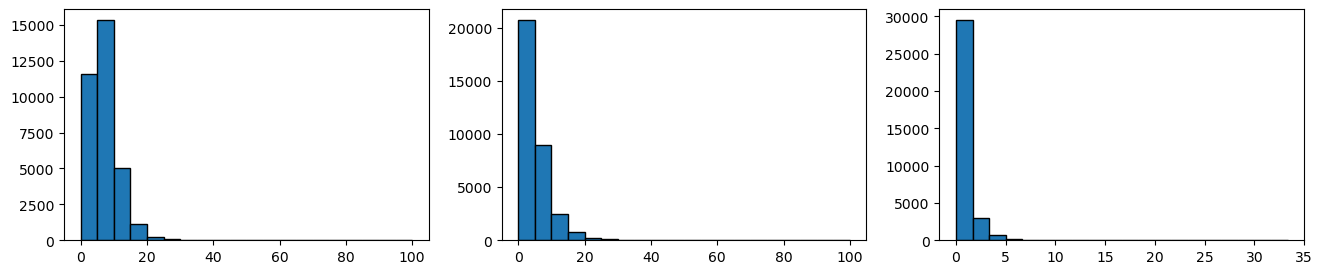

In [8]:
# histogram으로 비교
fig, axes = plt.subplots(1, 3, figsize=(16,3))

plt.subplot(1,3,1)
plt.hist(df['pct_carrier_delay'], bins=20, edgecolor='black')

plt.subplot(1,3,2)
plt.hist(df['pct_atc_delay'], bins=20, edgecolor='black')

plt.subplot(1,3,3)
plt.hist(df['pct_weather_delay'], bins=20, edgecolor='black')


# 시각적 분석 - 지연요인별 분석

<Axes: xlabel='airline', ylabel='pct_weather_delay'>

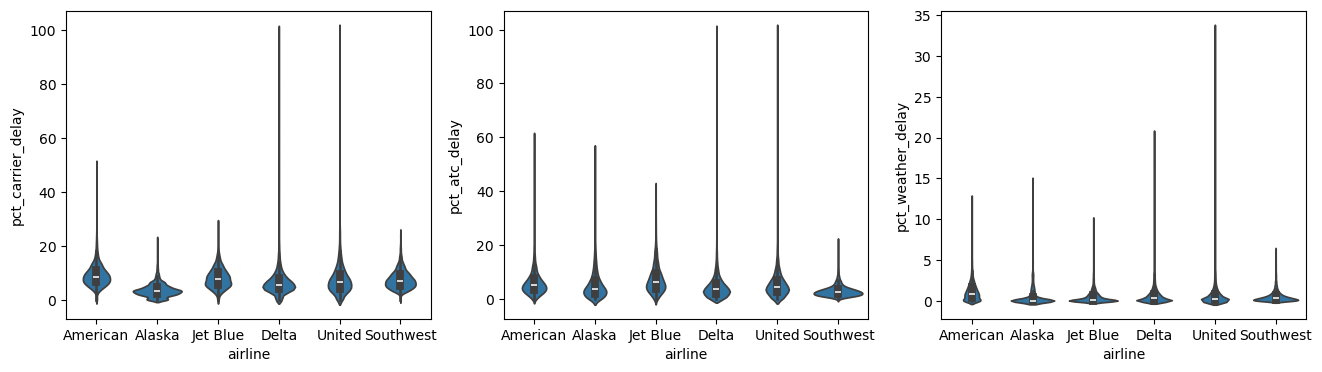

In [11]:
fig,axes = plt.subplots(1,3,figsize=(16,4))

sns.violinplot(data=df, x='airline', y='pct_carrier_delay', ax=axes[0])
sns.violinplot(data=df, x='airline', y='pct_atc_delay', ax=axes[1])
sns.violinplot(data=df, x='airline', y='pct_weather_delay', ax=axes[2])


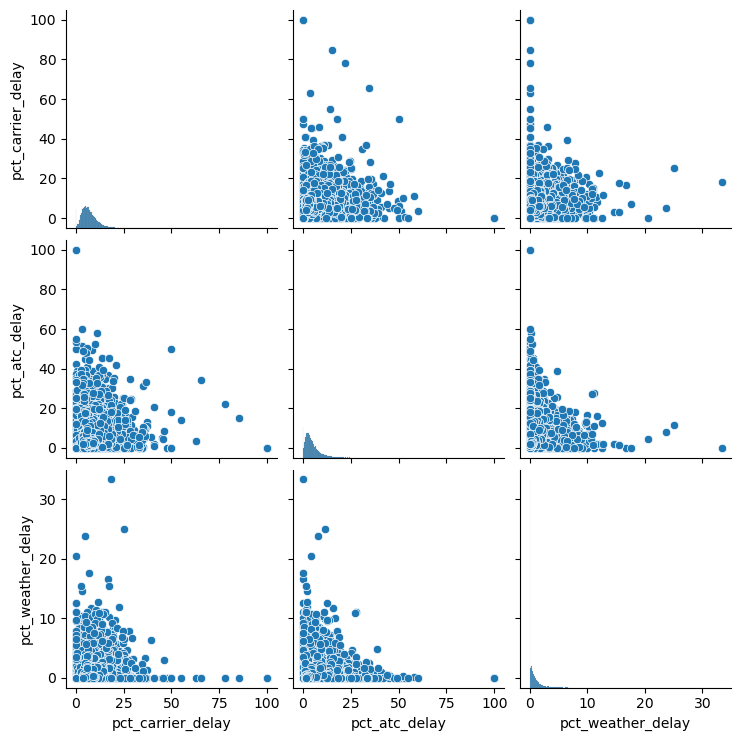

In [15]:
sns.pairplot(df)

<Axes: >

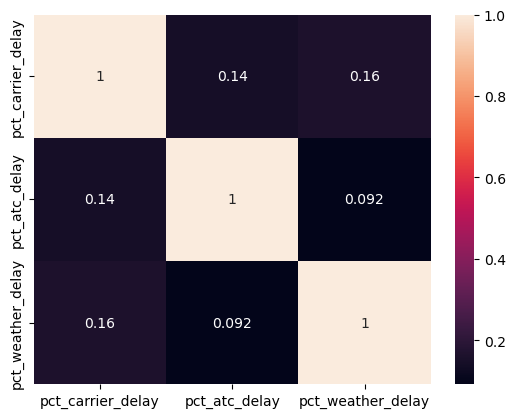

In [16]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)

1. 항공사

2. 관제

3. 날씨

# 결측치 처리

In [19]:
null_rows_carrier=df[df['pct_carrier_delay'].isnull()]
null_rows_carrier

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
4809,NaN,NaN,NaN,Jet Blue
6123,NaN,NaN,NaN,Jet Blue
7069,NaN,NaN,NaN,Delta
9241,NaN,NaN,NaN,Delta
12081,NaN,NaN,NaN,United
12541,NaN,NaN,NaN,United
13058,NaN,NaN,NaN,United
13534,NaN,NaN,NaN,United
13547,NaN,NaN,NaN,United
13996,NaN,NaN,NaN,United


In [25]:
df_clear = df.dropna()
df_clear.info(),df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33440 entries, 0 to 33467
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pct_carrier_delay  33440 non-null  float64
 1   pct_atc_delay      33440 non-null  float64
 2   pct_weather_delay  33440 non-null  float64
 3   airline            33440 non-null  object 
dtypes: float64(3), object(1)
memory usage: 1.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33468 entries, 0 to 33467
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pct_carrier_delay  33440 non-null  float64
 1   pct_atc_delay      33440 non-null  float64
 2   pct_weather_delay  33440 non-null  float64
 3   airline            33468 non-null  object 
dtypes: float64(3), object(1)
memory usage: 1.0+ MB


(None, None)

# 비교 분석

In [ ]:
# 클렌징 전후 데이터의 통계량 비교